In [1]:
import importlib.util
import sys
import subprocess

if importlib.util.find_spec("lightgbm") is None:
    print("LightGBM topilmadi. O'rnatilmoqda")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "lightgbm"])
else:
    print("lightGBM allaqachon o'rtnatilgan")

lightGBM allaqachon o'rtnatilgan


In [2]:
import numpy as np
import warnings
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from  lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")

rs=42
np.random.seed(rs)

print("kutubxona tayyor")

kutubxona tayyor


In [3]:
# model = XGBClassifier(
#     n_estimators = 200,
#     learning_rate=0.05,
#     max_depth=1,
#     num_leaves=31
#     random_state=42
# )

# model.fit(
#     X_train, 
#     y_train
# )
# y_pred = model

In [4]:
housing = fetch_california_housing(as_frame=True)

X = housing.data.copy()
y = housing.target.copy()

df = X.copy()
df["Target"]=y

print(f"Observation soni: {X.shape[0]:,}")
print(f"Feature soni: {X.shape[1]}")
print("\nFeaturelar:")
print(list(X.columns))
print("\nTarget:")
print(housing.target_names)
df.head()

Observation soni: 20,640
Feature soni: 8

Featurelar:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target:
['MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=rs
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (16512, 8)
Test: (4128, 8)


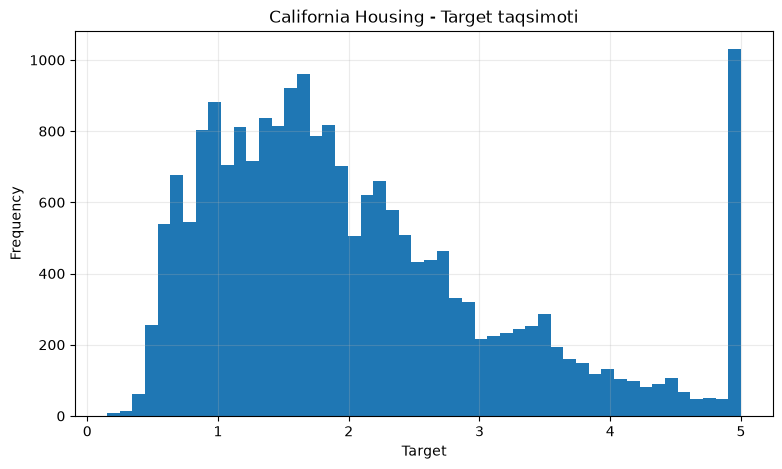

In [6]:
plt.figure(figsize=(9, 5))
plt.hist(y, bins=50)
plt.xlabel("Target")
plt.ylabel("Frequency")
plt.title("California Housing - Target taqsimoti")
plt.grid(alpha=0.25)
plt.show()

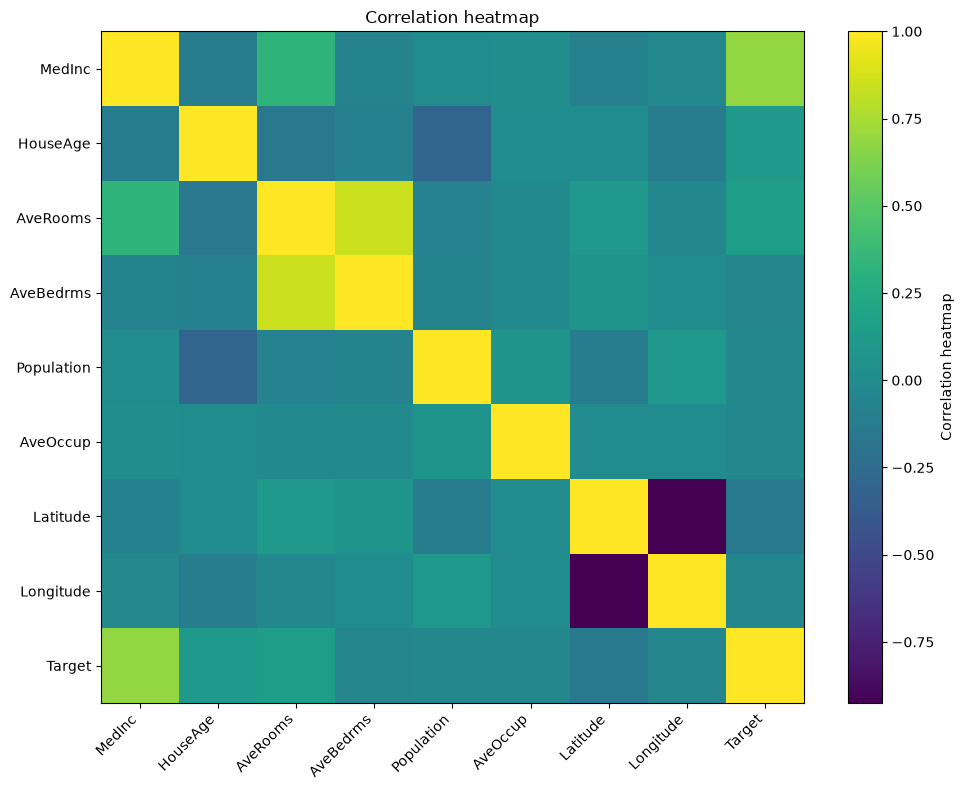

In [7]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation heatmap")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

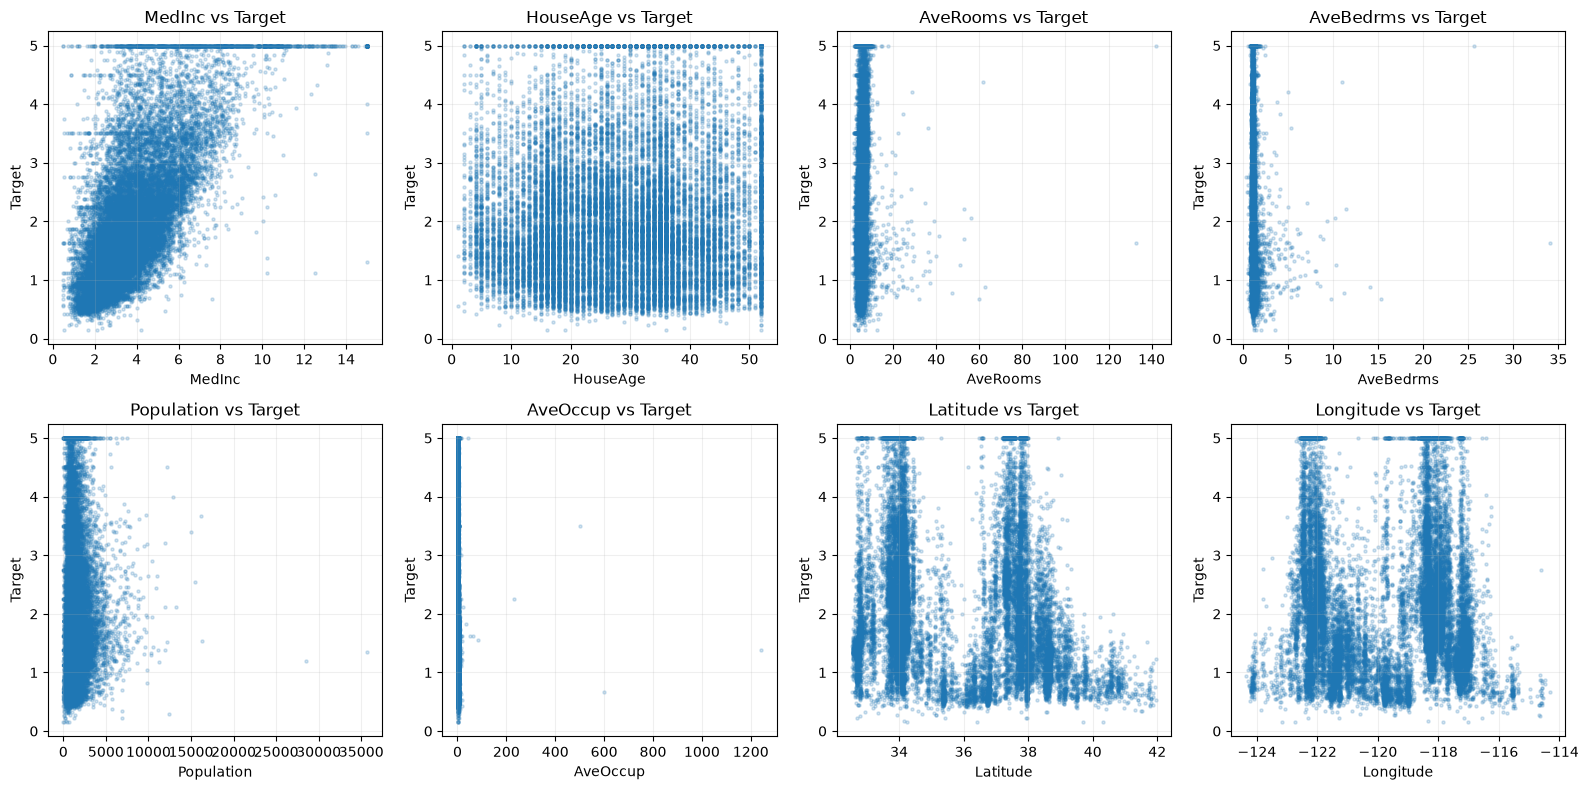

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for ax, feature in zip(axes, X.columns):
    ax.scatter(X[feature], y, s=5, alpha=0.20)
    ax.set_xlabel(feature)
    ax.set_ylabel("Target")
    ax.set_title(f"{feature} vs Target")
    ax.grid(alpha=0.2)


plt.tight_layout()
plt.show()

Model Natijalari


,Model,MAE,MSE,RMSE,R2
0,LightGBM,0.2966,0.2023,0.4498,0.8456
1,Random Forest,0.3267,0.2538,0.5038,0.8063
2,Decision Tree,0.4267,0.4308,0.6563,0.6713



RMSE bo'yicha eng kichik natija:
LightGBM -> 0.4498

R2 bo'yicha eng kichik natija:
LightGBM -> 0.6713


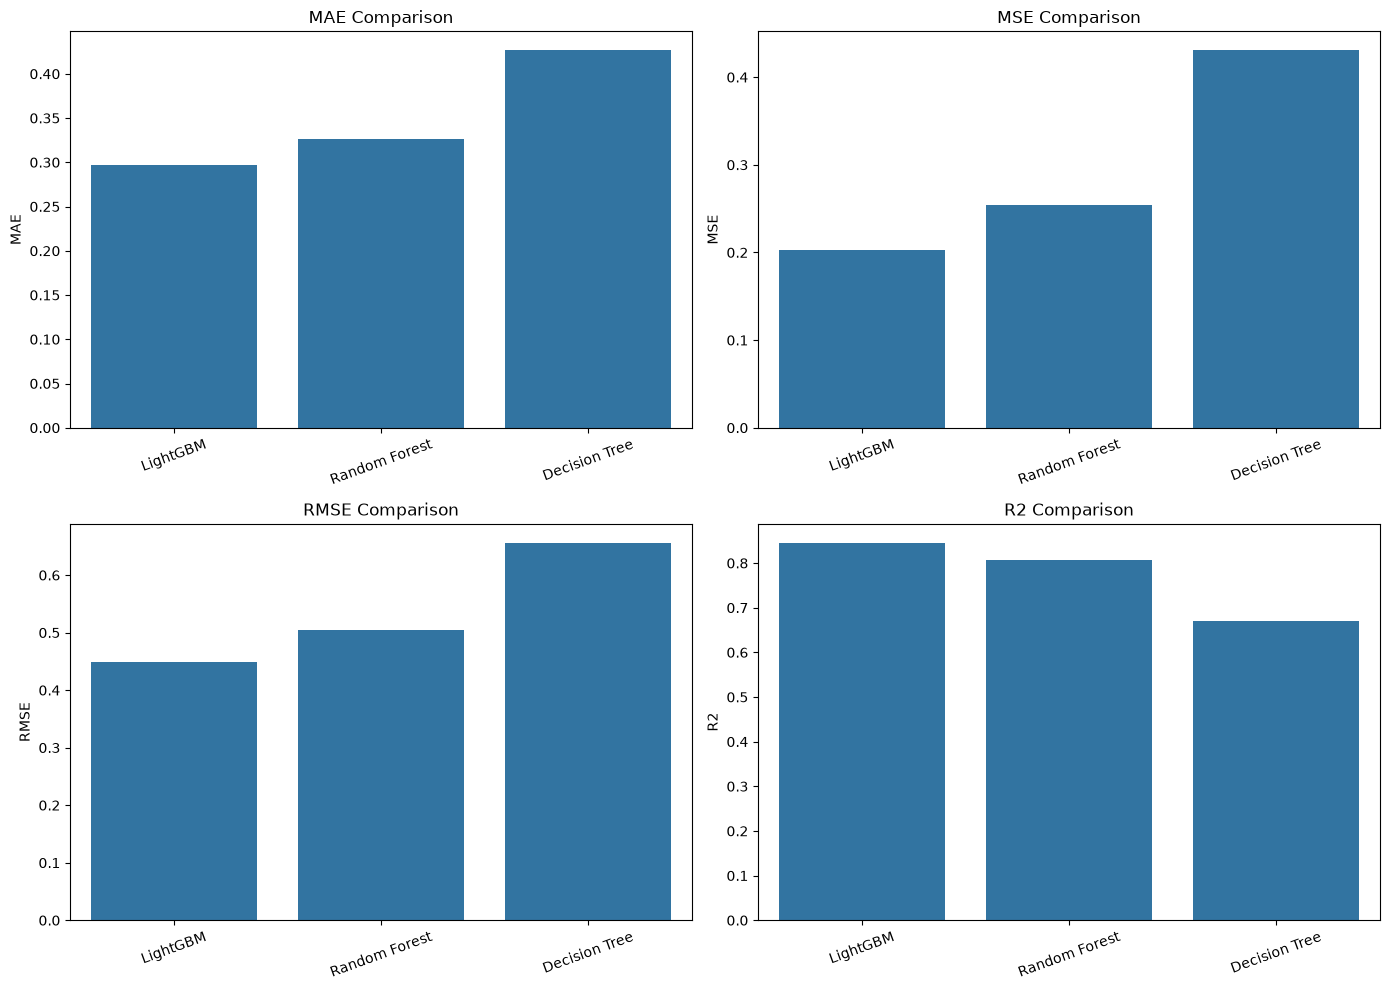

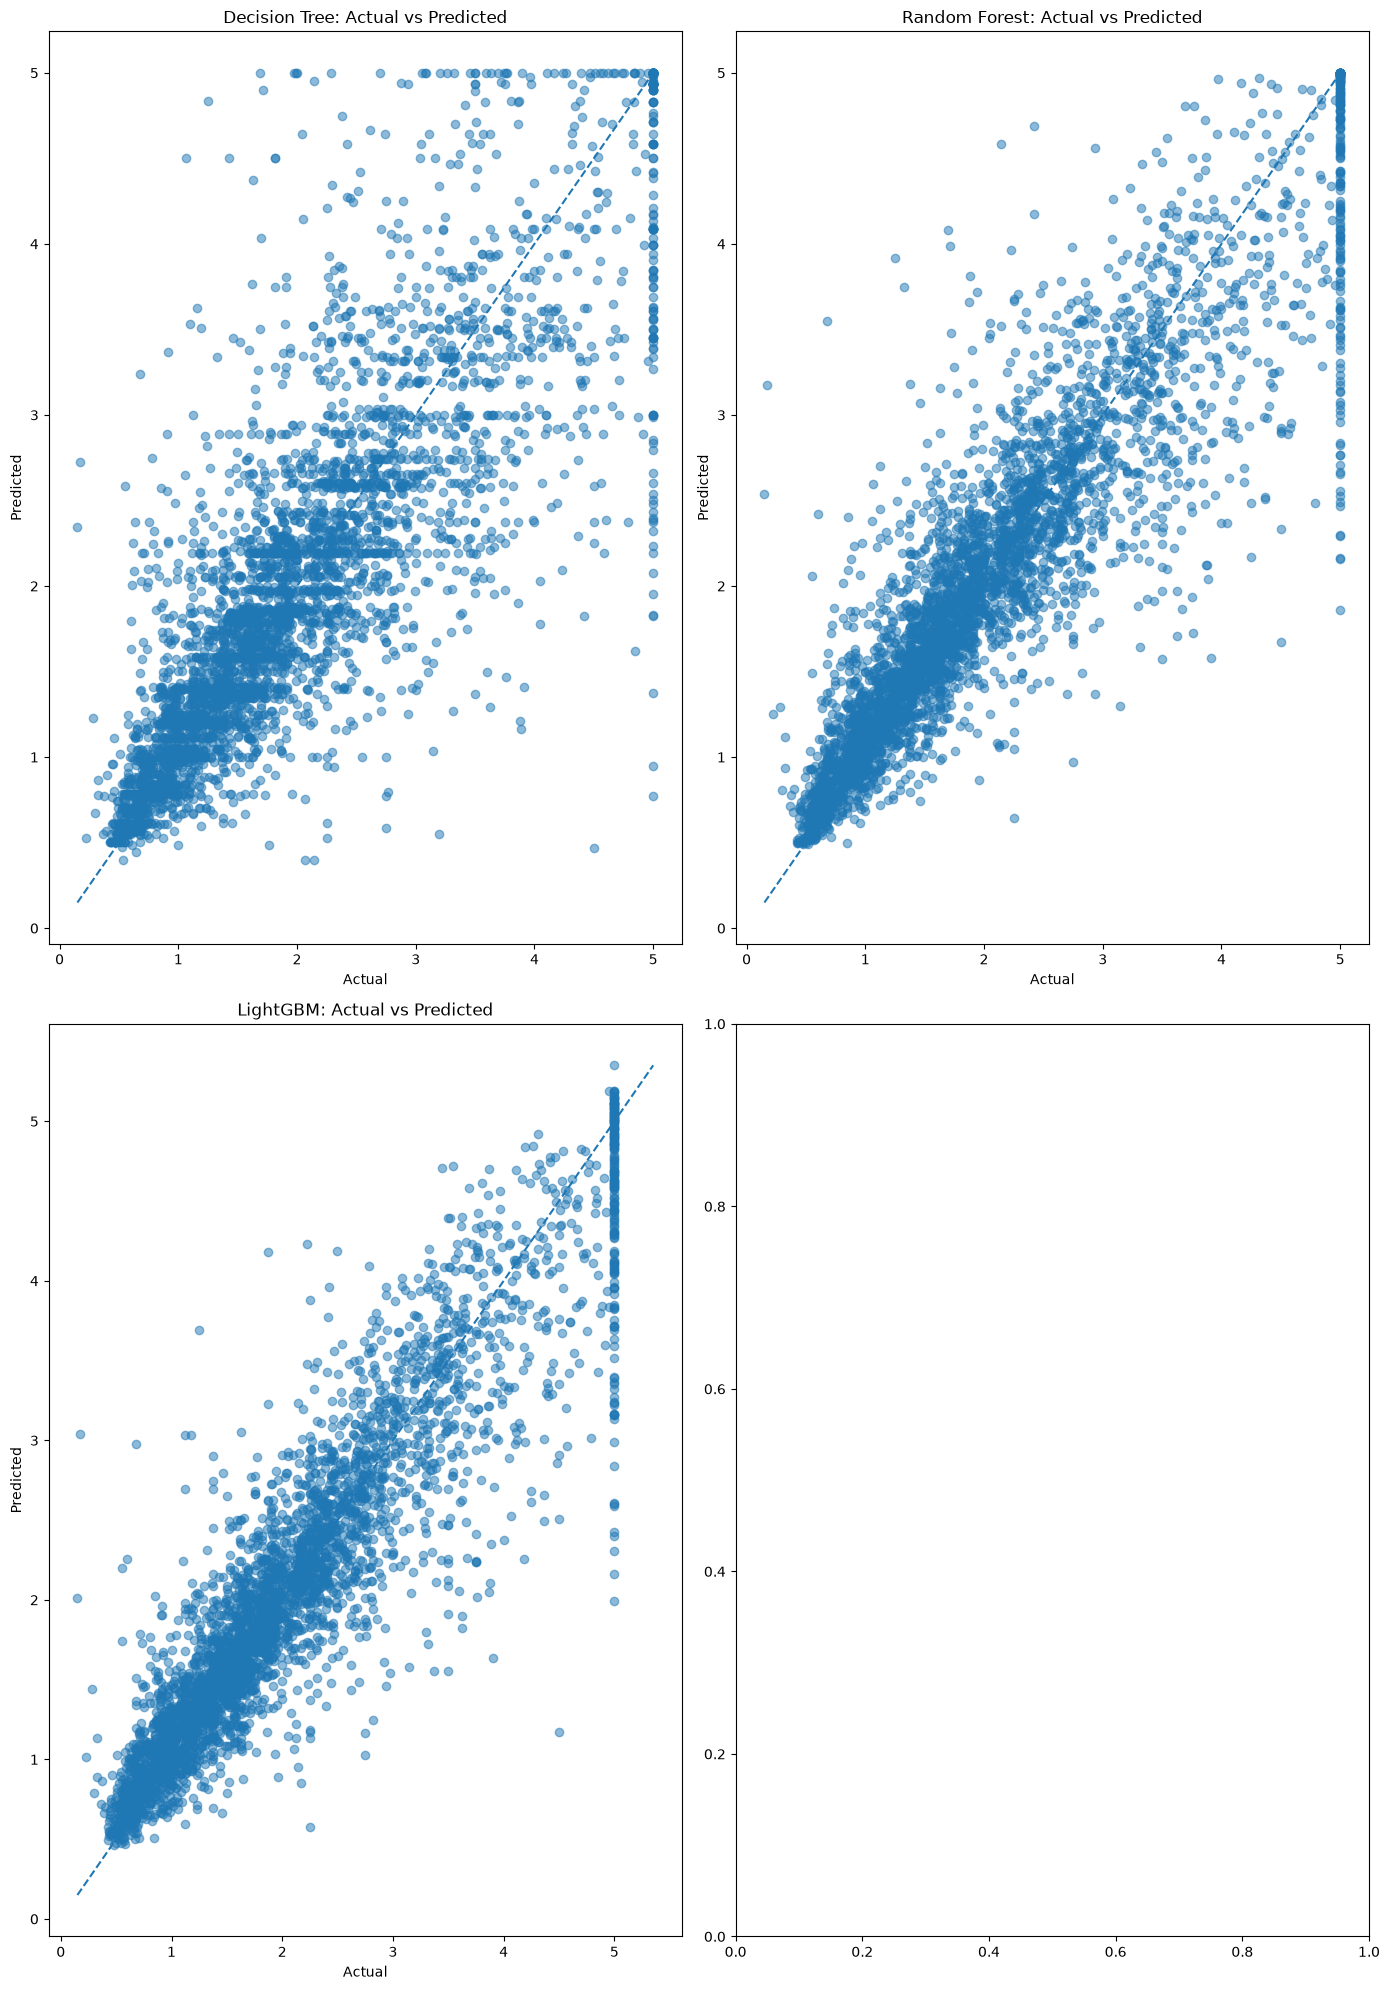


FINAL COMPARISON


,Model,MAE,RMSE,R2
0,LightGBM,0.2966,0.4498,0.8456
1,Random Forest,0.3267,0.5038,0.8063
2,Decision Tree,0.4267,0.6563,0.6713


In [9]:
models = {
    "Decision Tree": DecisionTreeRegressor(
        max_depth=12,
        random_state=rs
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_features=1.0,
        n_jobs=-1,
        random_state=rs
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        verbosity=-1,
        random_state=rs,
        n_jobs=-1
    )
}

results = []
predictions = {}

for name, model in models.items():
    # Model o'qitish
    model.fit(X_train, y_train)

    # Test Prediction
    y_pred = model.predict(X_test)

    # Prediction saqlash
    predictions[name] = y_pred

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2  =r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

# Natijalar jadvali

results_df = pd.DataFrame(results)

# RMSE bo'yicha tartiblash

results_df = results_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

print("=" * 70)
print("Model Natijalari")
print("=" * 70)

display(results_df.round(4))

# ENG YAXSHI MODELNI METRIKLARI BO'YICHA KO'RISH

best_rmse = results_df.loc[results_df["RMSE"].idxmin()]
best_r2 = results_df.loc[results_df["RMSE"].idxmax()]

print("\nRMSE bo'yicha eng kichik natija:")
print(best_rmse["Model"], "->", round(best_rmse["RMSE"], 4))

print("\nR2 bo'yicha eng kichik natija:")
print(best_rmse["Model"], "->", round(best_r2["R2"], 4))
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ["MAE", "MSE", "RMSE", "R2"]
for ax, metric in zip(axes.flat, metrics):
    sns.barplot(
        data=results_df,
        x="Model",
        y=metric,
        ax=ax
    )

    ax.set_title(f"{metric} Comparison")
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()
fig, axes = plt.subplots(2, 2, figsize=(14, 20))
for ax, (name, y_pred) in zip(
    axes.flat,
    predictions.items()
):
    ax.scatter(y_test, y_pred, alpha=0.5)
    # ideal prediction line
    min_value = min(y_test.min(), y_pred.min())
    max_value = max(y_test.max(), y_pred.max())
    ax.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )



    ax.set_title(f"{name}: Actual vs Predicted")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

plt.tight_layout()
plt.show()

comparison = results_df[
    ["Model", "MAE", "RMSE", "R2"]
].copy()

print("\n" + "=" * 70)
print("FINAL COMPARISON")
print("=" * 70)

display(comparison.round(4))
